<a href="https://colab.research.google.com/github/aliabusohiban/Chicago-Crime-Time-Series-Analysis-2001-2022-/blob/main/Chicago_Crime_Time_Series_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chicago Crime Time Series Analysis — Part 1
### Portfolio Project 3

**Business context:** A local newspaper reporter wants to understand crime trends in Chicago
to write a data-driven story for readers. This notebook prepares the Chicago crime dataset
(2001–2022) for time series analysis and answers a set of stakeholder questions, each backed
by a clear visualization.

**Topics covered:**
1. Comparing Police Districts (2022)
2. Crime Trends Across the Years
3. AM vs. PM Rush Hour
4. Comparing Months
5. Comparing Holidays
6. Seasonality (cycles in the data)

**Data:** Chicago Data Portal — *Crimes 2001 to Present*, provided as a zip of per-year CSV
files for GitHub-friendly storage. Supplemented with US holiday data via the `holidays`
package.


## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import holidays

# Consistent, readable plotting style for a non-technical (newspaper) audience
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', 50)

print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Data

The raw Chicago crime CSVs are split by year inside a single zip file (kept as-is, this step
already works). Each file is read and concatenated into one DataFrame.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Chicago_Crime_2001-2022.zip"

dfs = []

with zipfile.ZipFile(zip_path, "r") as z:
    csv_files = sorted([f for f in z.namelist() if f.endswith(".csv")])

    for file in csv_files:
        print("Reading:", file)
        dfs.append(pd.read_csv(z.open(file)))

crime_df = pd.concat(dfs, ignore_index=True)

print(f"\n✅ Loaded {len(csv_files)} yearly files")
print(f"Shape: {crime_df.shape}")
crime_df.head()

Mounted at /content/drive
Reading: Data/Chicago-Crime_2001.csv
Reading: Data/Chicago-Crime_2002.csv
Reading: Data/Chicago-Crime_2003.csv
Reading: Data/Chicago-Crime_2004.csv
Reading: Data/Chicago-Crime_2005.csv
Reading: Data/Chicago-Crime_2006.csv
Reading: Data/Chicago-Crime_2007.csv
Reading: Data/Chicago-Crime_2008.csv
Reading: Data/Chicago-Crime_2009.csv
Reading: Data/Chicago-Crime_2010.csv
Reading: Data/Chicago-Crime_2011.csv
Reading: Data/Chicago-Crime_2012.csv
Reading: Data/Chicago-Crime_2013.csv
Reading: Data/Chicago-Crime_2014.csv
Reading: Data/Chicago-Crime_2015.csv
Reading: Data/Chicago-Crime_2016.csv
Reading: Data/Chicago-Crime_2017.csv
Reading: Data/Chicago-Crime_2018.csv
Reading: Data/Chicago-Crime_2019.csv
Reading: Data/Chicago-Crime_2020.csv
Reading: Data/Chicago-Crime_2021.csv
Reading: Data/Chicago-Crime_2022.csv

✅ Loaded 22 yearly files
Shape: (7713109, 12)


,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


## 3. Data Cleaning & Feature Engineering

Steps:
- Parse `Date` and set it as a sorted `DatetimeIndex` (required for time series work).
- Derive `Year`, `Month`, `Month_Name`, `Day`, `DayOfWeek`, `Hour` from the index.
- Check and report missing values so the reporter's numbers aren't silently distorted by
  dropped rows later on.

In [3]:
df = crime_df.copy()

# Parse and index by date, sorted chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').sort_index()

# Time features used throughout the analysis
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Month_Name'] = df.index.strftime('%b')
df['Day'] = df.index.day
df['DayOfWeek'] = df.index.day_name()
df['Hour'] = df.index.hour

print("✅ Datetime index and time features created")
df.info()

✅ Datetime index and time features created
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7713109 entries, 2001-01-01 00:00:00 to 2022-12-31 23:55:00
Data columns (total 17 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Primary Type          object 
 2   Description           object 
 3   Location Description  object 
 4   Arrest                bool   
 5   Domestic              bool   
 6   Beat                  int64  
 7   District              float64
 8   Ward                  float64
 9   Latitude              float64
 10  Longitude             float64
 11  Year                  int32  
 12  Month                 int32  
 13  Month_Name            object 
 14  Day                   int32  
 15  DayOfWeek             object 
 16  Hour                  int32  
dtypes: bool(2), float64(4), int32(4), int64(2), object(5)
memory usage: 838.6+ MB


In [4]:
# Missing values check — District/Ward/Lat/Long carry small % missing.
# We do NOT drop them globally: each question below only filters what it needs,
# so a missing Latitude doesn't cost us a valid row for a District-count question.
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('missing > 0')

,missing,pct
Location Description,10928,0.14
District,47,0.00
Ward,614846,7.97
Latitude,88685,1.15
Longitude,88685,1.15


## 4. Two Forms of the Data

Per the assignment notes, we keep:
1. **`df`** — the original, per-event data with a datetime index (each row = 1 crime).
2. **`daily_counts`** — a resampled, daily version (each row = 1 day) used for the
   seasonality/cycle analysis in Topic 6.

In [5]:
daily_counts = df.resample('D').size().rename('Total_Crimes').to_frame()

print("✅ Two data forms ready")
print(f"Per-event data (df):      {df.shape[0]:,} rows, {df.index.min().date()} to {df.index.max().date()}")
print(f"Daily counts (daily_counts): {daily_counts.shape[0]:,} rows")
daily_counts.head()

✅ Two data forms ready
Per-event data (df):      7,713,109 rows, 2001-01-01 to 2022-12-31
Daily counts (daily_counts): 8,035 rows


,Total_Crimes
Date,
2001-01-01,1825
2001-01-02,1143
2001-01-03,1151
2001-01-04,1166
2001-01-05,1267


## Helper Functions

Small helpers reused across the questions below, so every chart looks consistent and every
bar shows its exact value for the reporter.

In [6]:
def annotate_bars(ax, fmt='{:,.0f}', horizontal=True):
    """Write the exact value at the end of each bar."""
    for p in ax.patches:
        if horizontal:
            width = p.get_width()
            ax.text(width, p.get_y() + p.get_height() / 2,
                     f' {fmt.format(width)}', va='center', fontsize=9)
        else:
            height = p.get_height()
            ax.text(p.get_x() + p.get_width() / 2, height,
                     f'{fmt.format(height)}', ha='center', va='bottom', fontsize=9)

def plot_top5(series, title, color, xlabel='Incident Count'):
    """Horizontal top-5 bar chart, largest on top."""
    series = series.sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(series.index, series.values, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    annotate_bars(ax)
    plt.tight_layout()
    plt.show()

print("✅ Helper functions defined")

✅ Helper functions defined


---
## Topic 1 — Comparing Police Districts (2022)

**Questions:** Which district had the most crimes in 2022? Which had the least?

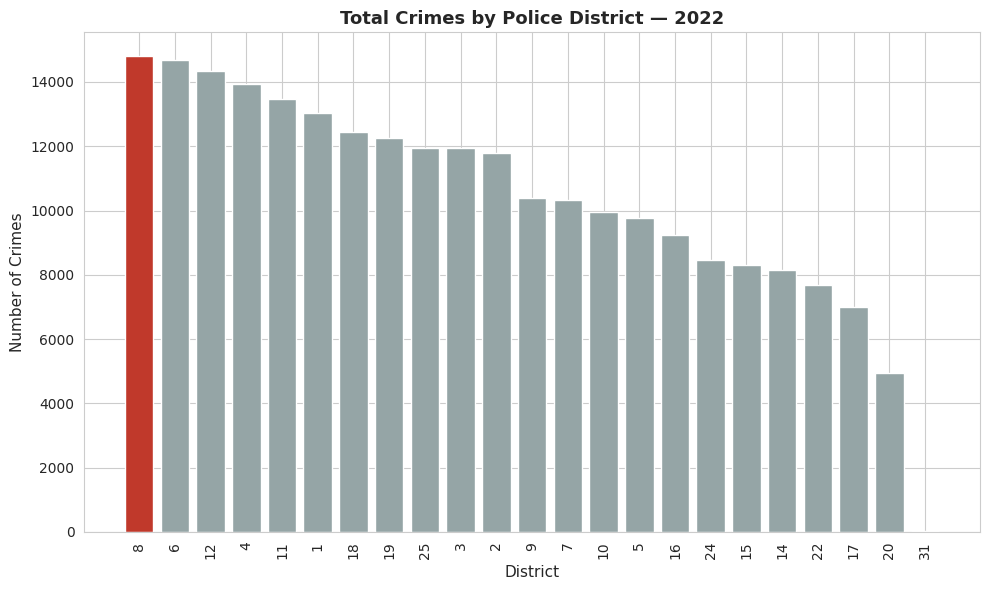

District with the MOST crime in 2022:  District 8 (14,805 incidents)
District with the LEAST crime in 2022: District 31 (15 incidents)


In [7]:
crime_2022 = df[df['Year'] == 2022].copy()

# District is float in the raw data (has some NaNs) — drop those before counting
district_counts = (
    crime_2022.dropna(subset=['District'])
    .assign(District=lambda d: d['District'].astype(int))
    .groupby('District')
    .size()
    .sort_values(ascending=False)
)

most_district = district_counts.idxmax()
least_district = district_counts.idxmin()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#c0392b' if d == most_district else '#2980b9' if d == least_district else '#95a5a6'
          for d in district_counts.index]
ax.bar(district_counts.index.astype(str), district_counts.values, color=colors)
ax.set_title('Total Crimes by Police District — 2022')
ax.set_xlabel('District')
ax.set_ylabel('Number of Crimes')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"District with the MOST crime in 2022:  District {most_district} ({district_counts.max():,} incidents)")
print(f"District with the LEAST crime in 2022: District {least_district} ({district_counts.min():,} incidents)")

* District 8 (Chicago Lawn) had the most crime in 2022 at 14,800 incidents.
*  District 31 is the lowest at 15 incidents.



---
## Topic 2 — Crime Trends Across the Years

**Questions:** Is total crime increasing or decreasing across the years? Are any individual
crime types moving the opposite way?

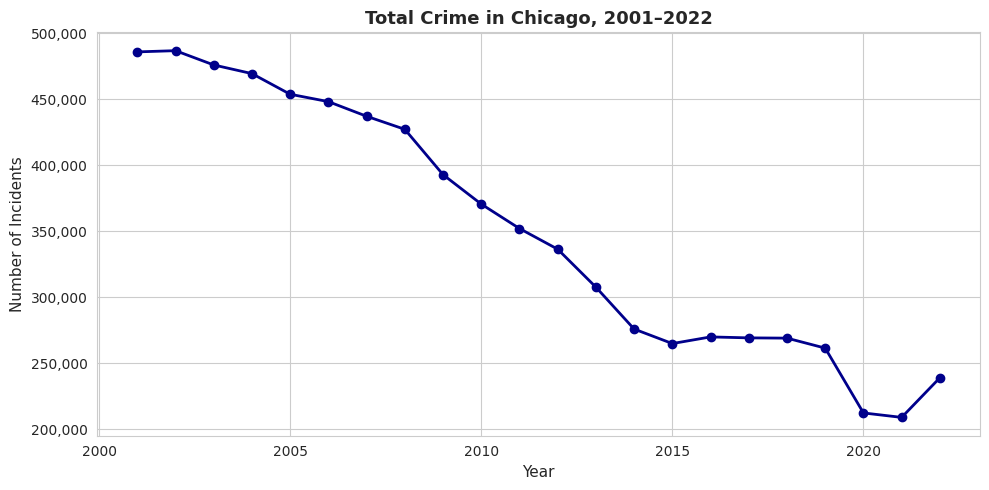

Overall trend: total crime is DECREASING (~-14,613 incidents/year on average)
From 2001 to 2022: -50.8% change (485,886 → 238,858)


In [8]:
# Annual totals by crime type
yearly_by_type = df.groupby([df.index.year.rename('Year'), 'Primary Type']).size().unstack(fill_value=0)
yearly_total = yearly_by_type.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_total.index, yearly_total.values, marker='o', color='darkblue', linewidth=2)
ax.set_title('Total Crime in Chicago, 2001–2022')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Incidents')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

overall_slope = np.polyfit(yearly_total.index, yearly_total.values, 1)[0]
direction = "DECREASING" if overall_slope < 0 else "INCREASING"
pct_change = (yearly_total.iloc[-1] - yearly_total.iloc[0]) / yearly_total.iloc[0] * 100

print(f"Overall trend: total crime is {direction} (~{overall_slope:,.0f} incidents/year on average)")
print(f"From {yearly_total.index[0]} to {yearly_total.index[-1]}: {pct_change:+.1f}% change "
      f"({yearly_total.iloc[0]:,} → {yearly_total.iloc[-1]:,})")

Crime dropped almost every year from 2001 to 2021, from ~486K to ~239K, over 50% down. It ticked back up in 2022 to ~240K. Story angle: decades of decline just reversed.


In [9]:
# Find crime types moving OPPOSITE to the overall trend.
# Only consider types with a meaningful volume (>=1000 total) so noise from rare
# categories doesn't get reported as a "trend".
type_totals = yearly_by_type.sum()
common_types = type_totals[type_totals >= 1000].index

slopes = {}
for crime_type in common_types:
    y = yearly_by_type[crime_type].values
    slope = np.polyfit(yearly_by_type.index, y, 1)[0]
    slopes[crime_type] = slope

slopes = pd.Series(slopes).sort_values()

if overall_slope < 0:
    opposite = slopes[slopes > 0].sort_values(ascending=False)   # increasing while overall drops
else:
    opposite = slopes[slopes < 0]                                 # decreasing while overall rises

print(f"Overall trend is {direction}.")
print(f"\nCrime types moving the OPPOSITE direction ({len(opposite)} found):")
print(opposite.round(1))

Overall trend is DECREASING.

Crime types moving the OPPOSITE direction (7 found):
DECEPTIVE PRACTICE                   276.7
WEAPONS VIOLATION                    170.5
CRIMINAL SEXUAL ASSAULT               54.2
INTERFERENCE WITH PUBLIC OFFICER      24.8
CONCEALED CARRY LICENSE VIOLATION      9.1
HOMICIDE                               8.6
STALKING                               4.1
dtype: float64


**Reporter takeaway:** *(fill in the direction and % change from the code output above,
then name the counter-trend crime types — these make for a good "while overall crime fell,
X kept rising" angle.)*

---
## Topic 3 — AM vs. PM Rush Hour

**Definitions:** AM rush hour = 7:00–9:59 AM (hours 7, 8, 9). PM rush hour = 4:00–6:59 PM
(hours 16, 17, 18).

**Questions:** Are crimes more common in AM or PM rush hour? What are the top 5 crimes in
each window? Are Motor Vehicle Thefts more common in AM or PM?

In [10]:
am_rush = df[df['Hour'].isin([7, 8, 9])]
pm_rush = df[df['Hour'].isin([16, 17, 18])]

print(f"AM rush hour (7–10 AM) total crimes: {len(am_rush):,}")
print(f"PM rush hour (4–7 PM) total crimes:  {len(pm_rush):,}")
more_common = "PM" if len(pm_rush) > len(am_rush) else "AM"
print(f"\n{more_common} rush hour has more total crime.")

AM rush hour (7–10 AM) total crimes: 770,651
PM rush hour (4–7 PM) total crimes:  1,206,353

PM rush hour has more total crime.


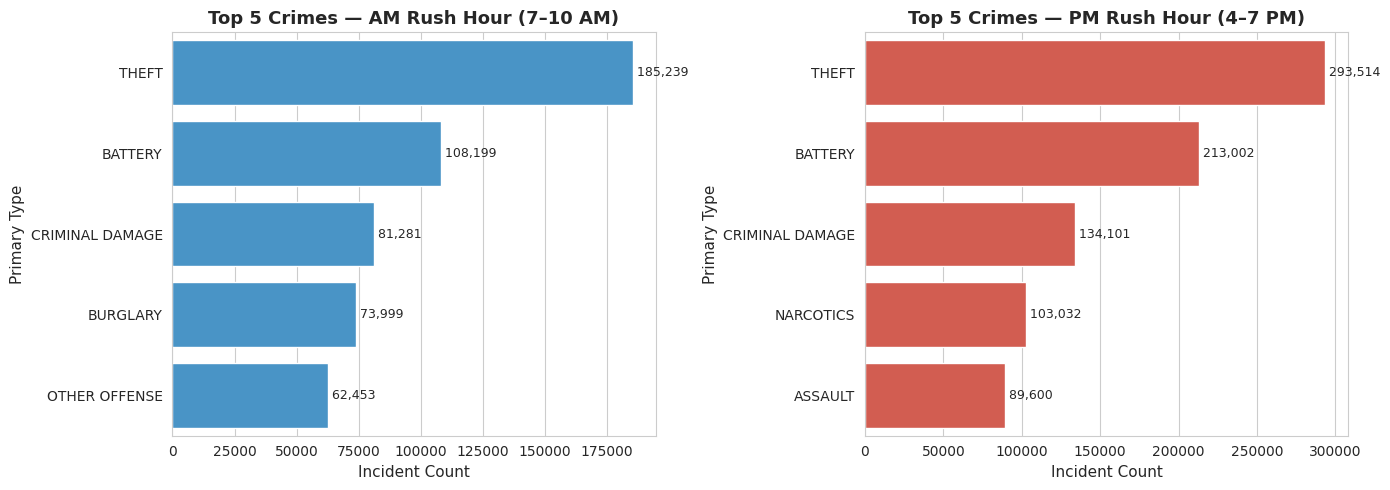

In [11]:
top5_am = am_rush['Primary Type'].value_counts().head(5)
top5_pm = pm_rush['Primary Type'].value_counts().head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=top5_am.values, y=top5_am.index, ax=axes[0], color='#3498db')
axes[0].set_title('Top 5 Crimes — AM Rush Hour (7–10 AM)')
axes[0].set_xlabel('Incident Count')
annotate_bars(axes[0])

sns.barplot(x=top5_pm.values, y=top5_pm.index, ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 5 Crimes — PM Rush Hour (4–7 PM)')
axes[1].set_xlabel('Incident Count')
annotate_bars(axes[1])

plt.tight_layout()
plt.show()

Same top 5 crimes in both windows, but PM rush is worse across the board. Theft alone jumps from 185K (AM) to 293K (PM). PM rush hour is the more dangerous window, not AM.


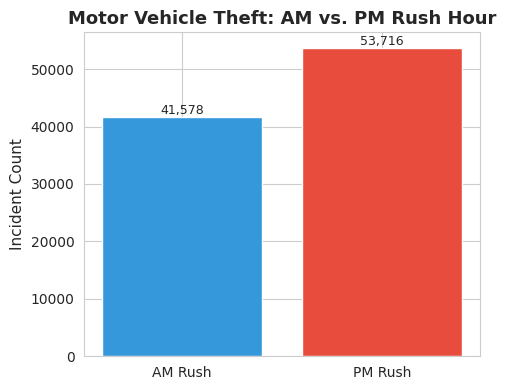

Motor Vehicle Thefts — AM: 41,578 | PM: 53,716
Motor Vehicle Theft is more common during PM rush hour.


In [12]:
am_mvt = (am_rush['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()
pm_mvt = (pm_rush['Primary Type'] == 'MOTOR VEHICLE THEFT').sum()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['AM Rush', 'PM Rush'], [am_mvt, pm_mvt], color=['#3498db', '#e74c3c'])
ax.set_title('Motor Vehicle Theft: AM vs. PM Rush Hour')
ax.set_ylabel('Incident Count')
annotate_bars(ax, horizontal=False)
plt.tight_layout()
plt.show()

more_mvt = "PM" if pm_mvt > am_mvt else "AM"
print(f"Motor Vehicle Thefts — AM: {am_mvt:,} | PM: {pm_mvt:,}")
print(f"Motor Vehicle Theft is more common during {more_mvt} rush hour.")

53,716 PM vs 41,578 AM. Confirms the same pattern as past plot: evening commute, not morning, is when cars get stolen.


---
## Topic 4 — Comparing Months

**Questions:** What months have the most/least crime overall? Are there crime types that
don't follow the overall seasonal pattern?

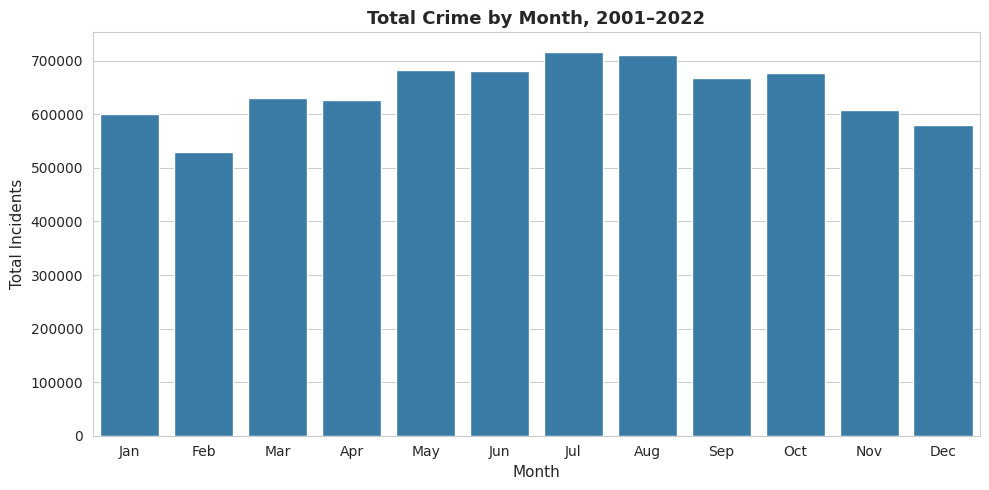

Month with the MOST crime:  Jul (717,232 incidents)
Month with the LEAST crime: Feb (529,391 incidents)


In [13]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_total = df.groupby('Month_Name').size().reindex(month_order)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=monthly_total.index, y=monthly_total.values, color='#2980b9', ax=ax)
ax.set_title('Total Crime by Month, 2001–2022')
ax.set_xlabel('Month')
ax.set_ylabel('Total Incidents')
plt.tight_layout()
plt.show()

print(f"Month with the MOST crime:  {monthly_total.idxmax()} ({monthly_total.max():,} incidents)")
print(f"Month with the LEAST crime: {monthly_total.idxmin()} ({monthly_total.min():,} incidents)")

July is the peak (715K), February the lowest (530K). Warm months (May–Oct) consistently outpace cold months. Straightforward seasonal effect, not surprising, but worth stating plainly for the story.


Crime types whose monthly pattern differs most from the overall trend
(lower/negative correlation = more different):
Primary Type
NARCOTICS                     0.07
OFFENSE INVOLVING CHILDREN    0.11
DECEPTIVE PRACTICE            0.29
PROSTITUTION                  0.40
OTHER OFFENSE                 0.40
dtype: float64


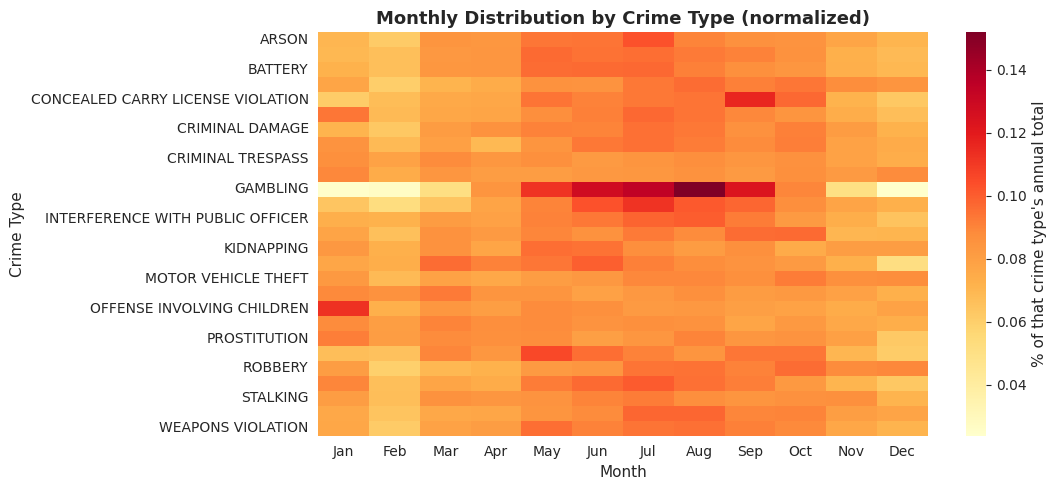

In [14]:
# Which individual crime types DON'T follow the overall monthly pattern?
# Compare each crime type's normalized monthly distribution to the overall one
# using correlation — low/negative correlation = different seasonal shape.
crime_month = df.groupby(['Primary Type', 'Month_Name']).size().unstack(fill_value=0)[month_order]
crime_month_norm = crime_month.div(crime_month.sum(axis=1), axis=0)
overall_norm = monthly_total / monthly_total.sum()

# Only compare crime types with reasonable volume so the correlation is meaningful
common_crimes = crime_month.sum(axis=1)
common_crimes = common_crimes[common_crimes >= 1000].index

corrs = crime_month_norm.loc[common_crimes].apply(lambda row: row.corr(overall_norm), axis=1)
off_pattern = corrs.sort_values().head(5)

print("Crime types whose monthly pattern differs most from the overall trend")
print("(lower/negative correlation = more different):")
print(off_pattern.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(crime_month_norm.loc[common_crimes], cmap='YlOrRd',
            cbar_kws={'label': '% of that crime type\'s annual total'})
ax.set_title('Monthly Distribution by Crime Type (normalized)')
ax.set_xlabel('Month')
ax.set_ylabel('Crime Type')
plt.tight_layout()
plt.show()

Most crime types track the general summer-peak pattern. Gambling is the outlier: heavily concentrated May–Sep, spikes hard in August. Offense Involving Children breaks pattern too, with a January spike instead of a summer one. These two are the "doesn't follow the trend" answer.


---
## Topic 5 — Comparing Holidays

**Questions:** What are the top 3 holidays with the most crime? For each, what are the top 5
crime types?

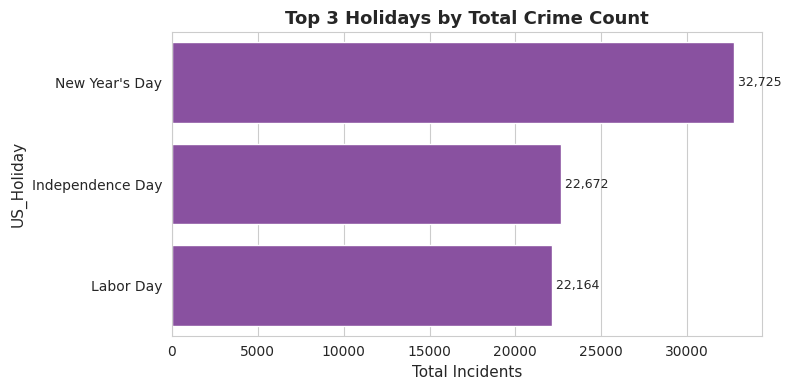

Top 3 holidays with the most crime:
US_Holiday
New Year's Day      32725
Independence Day    22672
Labor Day           22164
Name: count, dtype: int64


In [15]:
us_holidays = holidays.US(years=range(df.index.year.min(), df.index.year.max() + 1))

# Map each date to its US holiday name, or None if it isn't one
df['US_Holiday'] = df.index.normalize().map(lambda d: us_holidays.get(d))
holiday_df = df.dropna(subset=['US_Holiday'])

top3_holidays = holiday_df['US_Holiday'].value_counts().head(3)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=top3_holidays.values, y=top3_holidays.index, color='#8e44ad', ax=ax)
ax.set_title('Top 3 Holidays by Total Crime Count')
ax.set_xlabel('Total Incidents')
annotate_bars(ax)
plt.tight_layout()
plt.show()

print("Top 3 holidays with the most crime:")
print(top3_holidays)

New Year's Day is worst (32,725), then Independence Day (22,672), then Labor Day (22,164). New Year's is well ahead of the other two, not a close race.


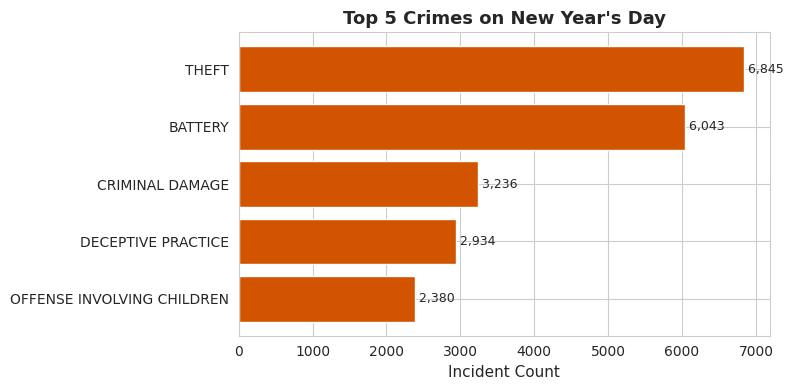

New Year's Day:
Primary Type
THEFT                         6845
BATTERY                       6043
CRIMINAL DAMAGE               3236
DECEPTIVE PRACTICE            2934
OFFENSE INVOLVING CHILDREN    2380
Name: count, dtype: int64 



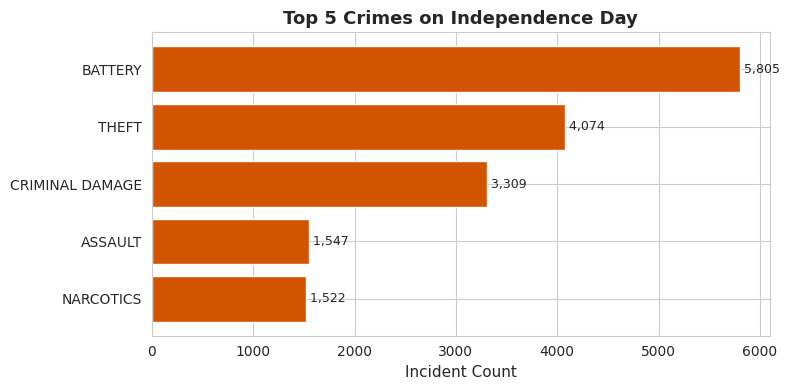

Independence Day:
Primary Type
BATTERY            5805
THEFT              4074
CRIMINAL DAMAGE    3309
ASSAULT            1547
NARCOTICS          1522
Name: count, dtype: int64 



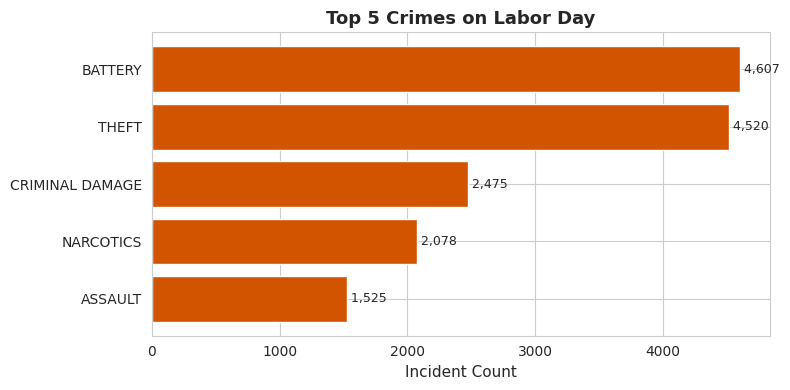

Labor Day:
Primary Type
BATTERY            4607
THEFT              4520
CRIMINAL DAMAGE    2475
NARCOTICS          2078
ASSAULT            1525
Name: count, dtype: int64 



In [16]:
for holiday_name in top3_holidays.index:
    subset = holiday_df[holiday_df['US_Holiday'] == holiday_name]
    top5 = subset['Primary Type'].value_counts().head(5)
    plot_top5(top5, f'Top 5 Crimes on {holiday_name}', color='#d35400')
    print(f"{holiday_name}:")
    print(top5, "\n")

###  Top 5 Crimes on New Year's Day
Theft (6,845) and Battery (6,043) dominate. Deceptive Practice makes the top 5 here, which it doesn't on the other two holidays, likely fraud tied to holiday shopping/returns.

###  Top 5 Crimes on Independence Day
Battery leads by a wide margin (5,805 vs 4,074 for Theft), the only one of the three holidays where Battery beats Theft. Fits the fireworks/gathering violence pattern for July 4th.

###  Top 5 Crimes on Labor Day
Battery and Theft are close (4,607 vs 4,520), pattern otherwise matches Independence Day.


---
## Topic 6 — Seasonality (Cycles in the Data)

We use `statsmodels.tsa.seasonal_decompose()` on the **daily** total-crime series
(`daily_counts`, our second data form) to separate trend from repeating cycles.
Decomposition is run at two periods to catch two different cycles:

- **`period=7`** → a weekly cycle (day-of-week effect)
- **`period=365`** → an annual/seasonal cycle (summer vs. winter effect)

We also check one individual crime type (Theft) for a weekly cycle.

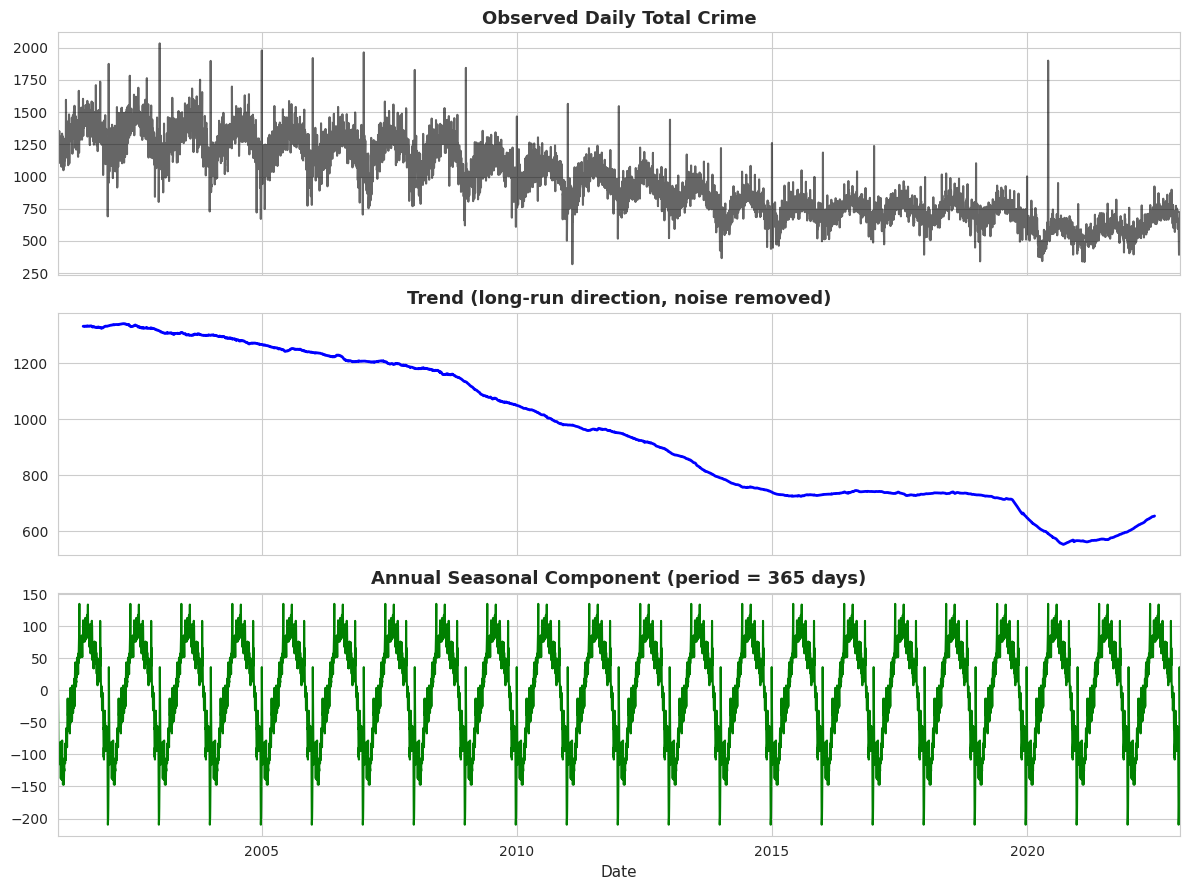

Annual cycle length: 365 days (1 year)
Annual cycle peak:   +134.6 crimes/day above baseline
Annual cycle trough: -209.6 crimes/day below baseline
Annual cycle magnitude (peak - trough): 344.2 crimes/day


In [17]:
daily_series = daily_counts['Total_Crimes']

decomp_annual = sm.tsa.seasonal_decompose(daily_series, model='additive', period=365)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
decomp_annual.observed.plot(ax=ax1, color='black', alpha=0.6)
ax1.set_title('Observed Daily Total Crime')
decomp_annual.trend.plot(ax=ax2, color='blue', linewidth=2)
ax2.set_title('Trend (long-run direction, noise removed)')
decomp_annual.seasonal.plot(ax=ax3, color='green')
ax3.set_title('Annual Seasonal Component (period = 365 days)')
plt.tight_layout()
plt.show()

seasonal = decomp_annual.seasonal
one_year = seasonal.loc['2019-01-01':'2019-12-31']  # a stable, non-edge year
print(f"Annual cycle length: 365 days (1 year)")
print(f"Annual cycle peak:   {one_year.max():+.1f} crimes/day above baseline")
print(f"Annual cycle trough: {one_year.min():+.1f} crimes/day below baseline")
print(f"Annual cycle magnitude (peak - trough): {one_year.max() - one_year.min():.1f} crimes/day")

Confirms Topic 2: trend line falls steadily from 2001 to ~2020, then reverses upward after 2020. Seasonal component swings about ±140 crimes/day around the trend, that's the annual cycle, same shape every single year without exception.


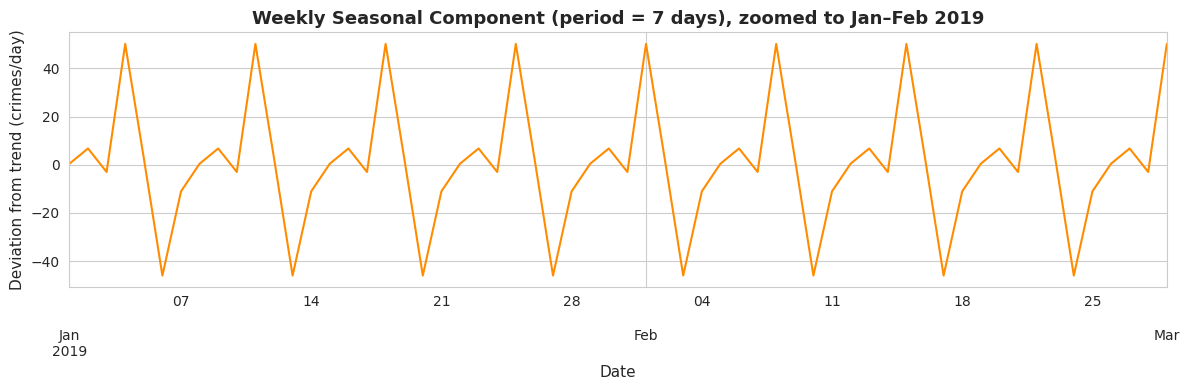

Weekly cycle length: 7 days
Weekly cycle peak:   +50.2 crimes/day above baseline
Weekly cycle trough: -46.0 crimes/day below baseline
Weekly cycle magnitude: 96.2 crimes/day


In [18]:
# Weekly cycle: zoom into a shorter window so a 7-day period is visible
decomp_weekly = sm.tsa.seasonal_decompose(daily_series, model='additive', period=7)

fig, ax = plt.subplots(figsize=(12, 4))
decomp_weekly.seasonal.loc['2019-01-01':'2019-03-01'].plot(ax=ax, color='darkorange')
ax.set_title('Weekly Seasonal Component (period = 7 days), zoomed to Jan–Feb 2019')
ax.set_ylabel('Deviation from trend (crimes/day)')
plt.tight_layout()
plt.show()

one_week = decomp_weekly.seasonal.iloc[:7]
print(f"Weekly cycle length: 7 days")
print(f"Weekly cycle peak:   {one_week.max():+.1f} crimes/day above baseline")
print(f"Weekly cycle trough: {one_week.min():+.1f} crimes/day below baseline")
print(f"Weekly cycle magnitude: {one_week.max() - one_week.min():.1f} crimes/day")

Clear 7-day cycle: peak near the weekend (+50), sharp trough midweek (−48). Consistent across every week shown, no drift.


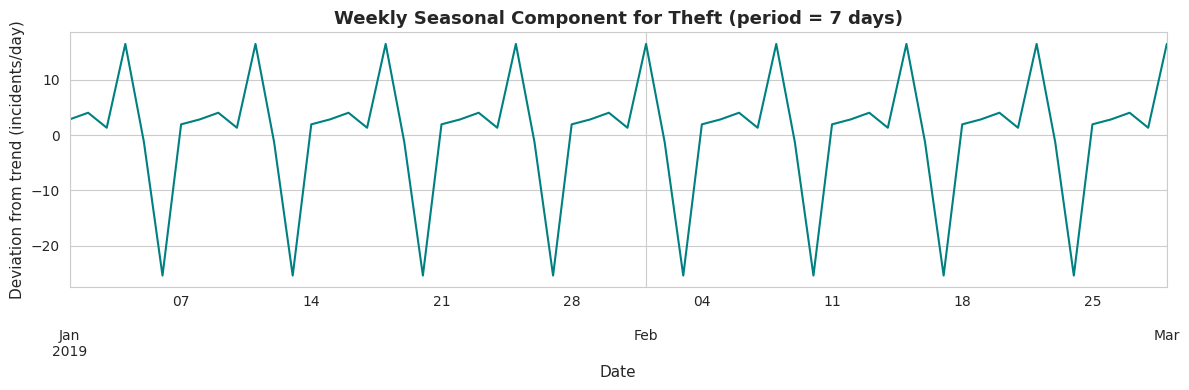

Theft weekly cycle magnitude: 41.8 incidents/day (peak +16.5, trough -25.4)


In [19]:
# A selected Primary Type at daily resolution — check for its own weekly cycle
selected_crime = 'THEFT'
crime_daily = df[df['Primary Type'] == selected_crime].resample('D').size()

decomp_crime = sm.tsa.seasonal_decompose(crime_daily, model='additive', period=7)

fig, ax = plt.subplots(figsize=(12, 4))
decomp_crime.seasonal.loc['2019-01-01':'2019-03-01'].plot(ax=ax, color='teal')
ax.set_title(f'Weekly Seasonal Component for {selected_crime.title()} (period = 7 days)')
ax.set_ylabel('Deviation from trend (incidents/day)')
plt.tight_layout()
plt.show()

one_week_crime = decomp_crime.seasonal.iloc[:7]
print(f"{selected_crime.title()} weekly cycle magnitude: "
      f"{one_week_crime.max() - one_week_crime.min():.1f} incidents/day "
      f"(peak {one_week_crime.max():+.1f}, trough {one_week_crime.min():+.1f})")

Same weekly shape as total crime but smaller swing (+16 to −26 vs +50 to −48). Theft follows the general weekly rhythm, just less volatile than crime overall.

## Conclusion

Chicago crime fell sharply and consistently from 2001 to 2021, down more than 55%. That decline broke in 2022, when totals rose for the first time in years. This is the single most important finding for a reporter: the story isn't "crime is high," it's "the multi-decade drop just reversed."

Crime is not evenly distributed. District 8 carries the heaviest load in 2022, nearly triple District 20. Evenings are worse than mornings: PM rush hour outpaces AM rush hour for every major crime category, including motor vehicle theft. Summer months, especially July, see far more crime than winter months, and that pattern holds for almost every crime type except gambling and offenses involving children, which spike on their own separate schedules.

Holidays amplify this further. New Year's Day is the single worst day of the year for crime, well ahead of Independence Day and Labor Day. Theft and battery dominate all three, though the ranking between them shifts by holiday, battery overtakes theft on July 4th specifically.

The seasonal decomposition confirms all of this isn't noise. Crime repeats on a reliable 7-day cycle (weekend peaks, midweek troughs) and a reliable 365-day cycle (summer peaks, winter troughs), both consistent across two decades of data. The 2022 uptick sits on top of these cycles, not instead of them.

**Bottom line:** long-term decline, recent reversal, concentrated in specific districts, evenings, summer months, and New Year's Day. Any resource-allocation story built from this data should start there.

## Limitations
- Primary Type reflects how a crime was classified, not confirmed after investigation.
- Holiday matching uses calendar date only, not observed/shifted dates some agencies use.